# Machine Learning for IT Service Management (ITSM)

## ABC Tech – Incident Management Optimization using Machine Learning

## Introduction

ABC Tech is a mid-size organization operating in the IT-enabled business segment for more than a decade. The organization receives approximately 22,000 to 25,000 IT incidents or tickets on a regular basis.

The organization follows ITIL best practices including:

• Incident Management  
• Problem Management  
• Change Management  
• Configuration Management  

Although the processes are mature and stable, recent customer survey results indicate poor satisfaction with incident management services. The management of ABC Tech is therefore exploring advanced technologies such as Machine Learning to improve the efficiency and effectiveness of IT Service Management (ITSM) processes.

Machine Learning can help predict incidents, automate ticket handling, improve resource planning, and reduce resolution time.

## Problem Statement

Despite following mature ITIL practices, ABC Tech is experiencing poor customer satisfaction regarding incident management.

The organization wants to leverage Machine Learning techniques to improve ITSM processes by predicting incidents, automating ticket categorization, forecasting incident volumes, and predicting change failures.

The goal of this project is to analyze ITSM incident data and develop machine learning models that can improve the incident management process.

## Project Objectives

The key objectives of this project are:

1. Predict High Priority Incidents  
   Identify Priority 1 and Priority 2 incidents before they escalate.

2. Forecast Incident Volume  
   Predict the number of incidents occurring in different time periods.

3. Auto Tag Tickets  
   Automatically assign tickets to the correct department and priority level.

4. Predict RFC Failure  
   Predict possible failure or misconfiguration of ITSM assets during change requests.

## Dataset Description

The dataset consists of ITSM incident records collected between the years 2012 and 2014.

Total Records: ~46,000

The data was extracted from a MySQL database and includes several attributes related to incident management.

Important features include:

• Incident_ID – Unique identifier for each incident  
• CI_Name – Configuration Item name  
• CI_Cat – Configuration Item category  
• CI_Subcat – Configuration Item subcategory  
• Impact – Impact level of the incident  
• Urgency – Urgency level of the incident  
• Priority – Priority assigned to the incident  
• Status – Current status of the ticket  
• No_of_Reassignments – Number of times the ticket was reassigned  
• Handle_Time_hrs – Time taken to handle the incident  
• Open_Time – Time when the incident was opened  
• Close_Time – Time when the incident was closed

## Data Extraction

The dataset was extracted from a MySQL database using Python.

The connection was established using database credentials and the required tables were queried using SQL.

The data was then loaded into a pandas DataFrame for further analysis and preprocessing.

## Data Cleaning

Several preprocessing steps were performed to prepare the dataset for analysis.

• Converted date columns into proper datetime format  
• Cleaned Handle_Time_hrs column and converted it to numeric format  
• Removed duplicate records  
• Handled missing values in important features  
• Ensured numeric columns were properly formatted

## Feature Engineering

New features were created to improve the predictive power of the machine learning models.

Examples include:

Resolution Time  
Resolution time was calculated using the difference between Close_Time and Open_Time.

Reopen Flag  
A binary feature indicating whether a ticket was reopened.

SLA Breach  
A feature indicating whether the ticket resolution time exceeded a predefined SLA threshold.

These engineered features helped capture important patterns in the dataset.

## Exploratory Data Analysis

Exploratory Data Analysis was conducted to understand the distribution of the dataset and identify important patterns.

Key analysis performed:

• Distribution of ticket priority levels  
• Relationship between urgency and priority  
• Impact vs priority analysis  
• Ticket reassignment patterns  
• Incident volume trends over time  
• Top configuration items generating incidents  
• Correlation between numerical features

EDA helped identify factors influencing incident priority and resolution time.

## Data Preprocessing

Before building machine learning models, the dataset was prepared using several preprocessing techniques.

Steps performed:

• Train-test split of the dataset  
• Encoding categorical variables  
• Feature scaling using StandardScaler  
• Combining numerical and categorical features

Feature scaling ensured that numerical variables were standardized and suitable for machine learning algorithms.

## Model Building

Two machine learning models were developed to predict incident priority.

Logistic Regression  
A baseline classification model used to understand the relationship between input features and incident priority.

Random Forest  
An ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy.

The dataset was divided into training and testing sets to evaluate the performance of the models.

## Model Evaluation

The models were evaluated using several classification metrics:

• Accuracy  
• Precision  
• Recall  
• F1 Score  
• Confusion Matrix  
• ROC Curve

Random Forest achieved better performance compared to Logistic Regression, indicating that ensemble methods capture complex patterns more effectively.

## Feature Importance

Feature importance analysis was performed using the Random Forest model.

The analysis revealed that the following features had significant influence on incident priority prediction:

• Impact  
• Urgency  
• Number of Reassignments  
• Handle Time  
• Configuration Item Category

Understanding these important features helps organizations focus on key drivers of incident priority.

## Business Insights

Key insights derived from the analysis include:

• High urgency and impact strongly influence ticket priority.  
• Tickets with frequent reassignment tend to have longer resolution times.  
• Certain configuration items generate a large number of incidents.  
• Incident volume varies across different periods.

These insights can help organizations optimize their incident management process.

## Business Recommendations

Based on the analysis, the following recommendations are proposed:

• Implement machine learning models to predict incident priority automatically.  
• Reduce ticket reassignment by improving ticket routing mechanisms.  
• Monitor configuration items that generate frequent incidents.  
• Use incident forecasting to improve resource allocation and planning.

## Conclusion

This project demonstrated how machine learning techniques can improve IT Service Management processes.

Using historical incident data, predictive models were developed to classify incident priority and analyze factors influencing incident resolution.

The Random Forest model provided better predictive performance compared to Logistic Regression.

Implementing such predictive systems can help organizations proactively manage incidents, reduce resolution time, and improve customer satisfaction.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)


In [2]:
!pip install mysql-connector-python
!pip install pymysql

In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host="18.136.157.135",
    user="dm_team",
    password="DM!$Team@&27920!",
    database="project_itsm"
)

cursor = conn.cursor()

cursor.execute("SHOW TABLES;")

for table in cursor.fetchall():
    print(table)

query = "SELECT * FROM dataset_list;"
df = pd.read_sql(query, conn)

print(df.head())

conn.close()

('dataset_list',)
     CI_Name          CI_Cat              CI_Subcat        WBS Incident_ID  \
0  SUB000508  subapplication  Web Based Application  WBS000162   IM0000004   
1  WBA000124     application  Web Based Application  WBS000088   IM0000005   
2  DTA000024     application    Desktop Application  WBS000092   IM0000006   
3  WBA000124     application  Web Based Application  WBS000088   IM0000011   
4  WBA000124     application  Web Based Application  WBS000088   IM0000012   

   Status Impact Urgency Priority   number_cnt  ...       Reopen_Time  \
0  Closed      4       4        4  0.601292279  ...                     
1  Closed      3       3        3  0.415049969  ...  02-12-2013 12:31   
2  Closed     NS       3       NA  0.517551335  ...                     
3  Closed      4       4        4  0.642927218  ...                     
4  Closed      4       4        4  0.345258343  ...                     

      Resolved_Time        Close_Time Handle_Time_hrs  \
0  04-11-2013 13:

In [4]:
pd.set_option("display.max_columns", None)

In [5]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,incident,KM0000553,closed,26,05-02-2012 13:32,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,incident,KM0000611,closed,33,12-03-2012 15:44,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,request for information,KM0000339,closed,3,29-03-2012 12:36,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,incident,KM0000611,closed,13,17-07-2012 11:49,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,incident,KM0000611,closed,2,10-08-2012 11:01,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [6]:
df.shape

(46606, 25)

In [7]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   CI_Name                     46606 non-null  object
 1   CI_Cat                      46606 non-null  object
 2   CI_Subcat                   46606 non-null  object
 3   WBS                         46606 non-null  object
 4   Incident_ID                 46606 non-null  object
 5   Status                      46606 non-null  object
 6   Impact                      46606 non-null  object
 7   Urgency                     46606 non-null  object
 8   Priority                    46606 non-null  object
 9   number_cnt                  46606 non-null  object
 10  Category                    46606 non-null  object
 11  KB_number                   46606 non-null  object
 12  Alert_Status                46606 non-null  object
 13  No_of_Reassignments         46606 non-null  ob

In [9]:
df.describe()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,Category,KB_number,Alert_Status,No_of_Reassignments,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
count,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606,46606
unique,3019,13,65,274,46606,2,6,6,6,46606,4,1825,1,42,34636,2245,33628,34528,30639,15,50,43060,25,5,233
top,SUB000456,application,Server Based Application,WBS000073,IM0000004,Closed,4,4,4,0.601292279,incident,KM0001106,closed,0,24-03-2014 08:54,,,02-10-2013 15:20,0,Other,1,#MULTIVALUE,,,
freq,3050,32900,18811,13342,1,46597,22556,22588,22717,1,37748,1106,46606,27468,7,44322,1780,21,236,16470,43058,3434,45384,46046,46046


In [10]:
df.describe(include='O').T

,count,unique,top,freq
CI_Name,46606,3019,SUB000456,3050
CI_Cat,46606,13,application,32900
CI_Subcat,46606,65,Server Based Application,18811
WBS,46606,274,WBS000073,13342
Incident_ID,46606,46606,IM0000004,1
Status,46606,2,Closed,46597
Impact,46606,6,4,22556
Urgency,46606,6,4,22588
Priority,46606,6,4,22717
number_cnt,46606,46606,0.601292279,1


In [11]:
df.isna().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Incident_ID                   0
Status                        0
Impact                        0
Urgency                       0
Priority                      0
number_cnt                    0
Category                      0
KB_number                     0
Alert_Status                  0
No_of_Reassignments           0
Open_Time                     0
Reopen_Time                   0
Resolved_Time                 0
Close_Time                    0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Related_Interaction           0
No_of_Related_Incidents       0
No_of_Related_Changes         0
Related_Change                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.nunique().sort_values(ascending=False)

Incident_ID                   46606
number_cnt                    46606
Related_Interaction           43060
Open_Time                     34636
Close_Time                    34528
Resolved_Time                 33628
Handle_Time_hrs               30639
CI_Name                        3019
Reopen_Time                    2245
KB_number                      1825
WBS                             274
Related_Change                  233
CI_Subcat                        65
No_of_Related_Interactions       50
No_of_Reassignments              42
No_of_Related_Incidents          25
Closure_Code                     15
CI_Cat                           13
Priority                          6
Urgency                           6
Impact                            6
No_of_Related_Changes             5
Category                          4
Status                            2
Alert_Status                      1
dtype: int64

In [14]:
df['Priority'].value_counts(dropna=False)

Priority
4     22717
5     16486
3      5323
NA     1380
2       697
1         3
Name: count, dtype: int64

In [15]:
df['Impact'].value_counts(dropna=False)

Impact
4     22556
5     16741
3      5234
NS     1380
2       692
1         3
Name: count, dtype: int64

In [16]:
df['Urgency'].value_counts(dropna=False)

Urgency
4               22588
5               16779
3                6536
2                 696
1                   6
5 - Very Low        1
Name: count, dtype: int64

In [17]:
df['Status'].value_counts()

Status
Closed              46597
Work in progress        9
Name: count, dtype: int64

In [18]:
df_model = df.copy()

In [19]:
def clean_urgency(x):
    """
    Convert values like 4, '4', '5 - Very Low' -> integer (1-5).
    If no digit found, return NaN.
    """
    s = str(x).strip()
    for ch in s:
        if ch.isdigit():
            return int(ch)
    return np.nan

df_model["Urgency"] = df_model["Urgency"].apply(clean_urgency)

df_model["Urgency"].value_counts(dropna=False)

Urgency
4    22588
5    16780
3     6536
2      696
1        6
Name: count, dtype: int64

In [20]:
def clean_impact(x):
    """
    Convert '1','2',...,'5' to int.
    'NS' or other non-digit -> NaN.
    """
    s = str(x).strip()
    return int(s) if s.isdigit() else np.nan

df_model["Impact"] = df_model["Impact"].apply(clean_impact)

df_model["Impact"].value_counts(dropna=False)

Impact
4.0    22556
5.0    16741
3.0     5234
NaN     1380
2.0      692
1.0        3
Name: count, dtype: int64

In [21]:
df_model = df_model[~df_model["Priority"].isna()].copy()

df_model = df_model[
    ~df_model["Impact"].isna() &
    ~df_model["Urgency"].isna()
].copy()

df_model["Priority"] = df_model["Priority"].astype(int)

In [22]:
df_model["Priority"].value_counts(dropna=False)

Priority
4    22717
5    16486
3     5323
2      697
1        3
Name: count, dtype: int64

In [23]:
df_model.shape

(45226, 25)

In [24]:
df_model["Open_Time"] = pd.to_datetime(df_model["Open_Time"], format="%d-%m-%Y %H:%M")
df_model["Reopen_Time"] = pd.to_datetime(df_model["Reopen_Time"], format="%d-%m-%Y %H:%M")
df_model["Resolved_Time"] = pd.to_datetime(df_model["Resolved_Time"], format="%d-%m-%Y %H:%M")
df_model["Close_Time"] = pd.to_datetime(df_model["Close_Time"], format="%d-%m-%Y %H:%M")

In [25]:
df_model["Handle_Time_hours"] = (
    df_model["Handle_Time_hrs"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_model["Handle_Time_hours"] = pd.to_numeric(
    df_model["Handle_Time_hours"],
    errors="coerce"
)

In [26]:
df_model["Handle_Time_hours"].describe()

count    14662.000000
mean         5.675384
std         26.900319
min          0.000000
25%          0.178056
50%          0.473611
75%          0.873056
max       2050.360000
Name: Handle_Time_hours, dtype: float64

In [27]:
df_model["Resolution_Time"] = (
    df_model["Close_Time"] - df_model["Open_Time"]
).dt.total_seconds()/3600

In [28]:
df_model["SLA_Breach"] = (df_model["Resolution_Time"] > 24).astype(int)

In [29]:
def hours_to_hms(hours):
    if pd.isna(hours):
        return None
    
    total_seconds = int(hours * 3600)
    
    hh = total_seconds // 3600
    mm = (total_seconds % 3600) // 60
    ss = total_seconds % 60
    
    return f"{hh:02d}:{mm:02d}:{ss:02d}"

df_model["Handle_Time_HHMMSS"] = df_model["Handle_Time_hours"].apply(hours_to_hms)

In [30]:
df_model[["Handle_Time_hrs", "Handle_Time_hours", "Handle_Time_HHMMSS"]].head()

,Handle_Time_hrs,Handle_Time_hours,Handle_Time_HHMMSS
0,"3,87,16,91,111",NaN,None
1,"4,35,47,86,389",NaN,None
3,"4,32,18,33,333",NaN,None
4,"3,38,39,03,333",NaN,None
5,"3,38,34,36,944",NaN,None


In [31]:
df_model.drop(columns=["Handle_Time_hrs"], inplace=True) 

In [32]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45226 entries, 0 to 46605
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     45226 non-null  object        
 1   CI_Cat                      45226 non-null  object        
 2   CI_Subcat                   45226 non-null  object        
 3   WBS                         45226 non-null  object        
 4   Incident_ID                 45226 non-null  object        
 5   Status                      45226 non-null  object        
 6   Impact                      45226 non-null  float64       
 7   Urgency                     45226 non-null  int64         
 8   Priority                    45226 non-null  int64         
 9   number_cnt                  45226 non-null  object        
 10  Category                    45226 non-null  object        
 11  KB_number                   45226 non-null  object        


In [33]:
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols

['Impact',
 'Urgency',
 'Priority',
 'Handle_Time_hours',
 'Resolution_Time',
 'SLA_Breach']

In [34]:
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['CI_Name',
 'CI_Cat',
 'CI_Subcat',
 'WBS',
 'Incident_ID',
 'Status',
 'number_cnt',
 'Category',
 'KB_number',
 'Alert_Status',
 'No_of_Reassignments',
 'Closure_Code',
 'No_of_Related_Interactions',
 'Related_Interaction',
 'No_of_Related_Incidents',
 'No_of_Related_Changes',
 'Related_Change',
 'Handle_Time_HHMMSS']

In [35]:
date_cols = df_model.select_dtypes(include=['datetime64[ns]']).columns.tolist()
date_cols

['Open_Time', 'Reopen_Time', 'Resolved_Time', 'Close_Time']

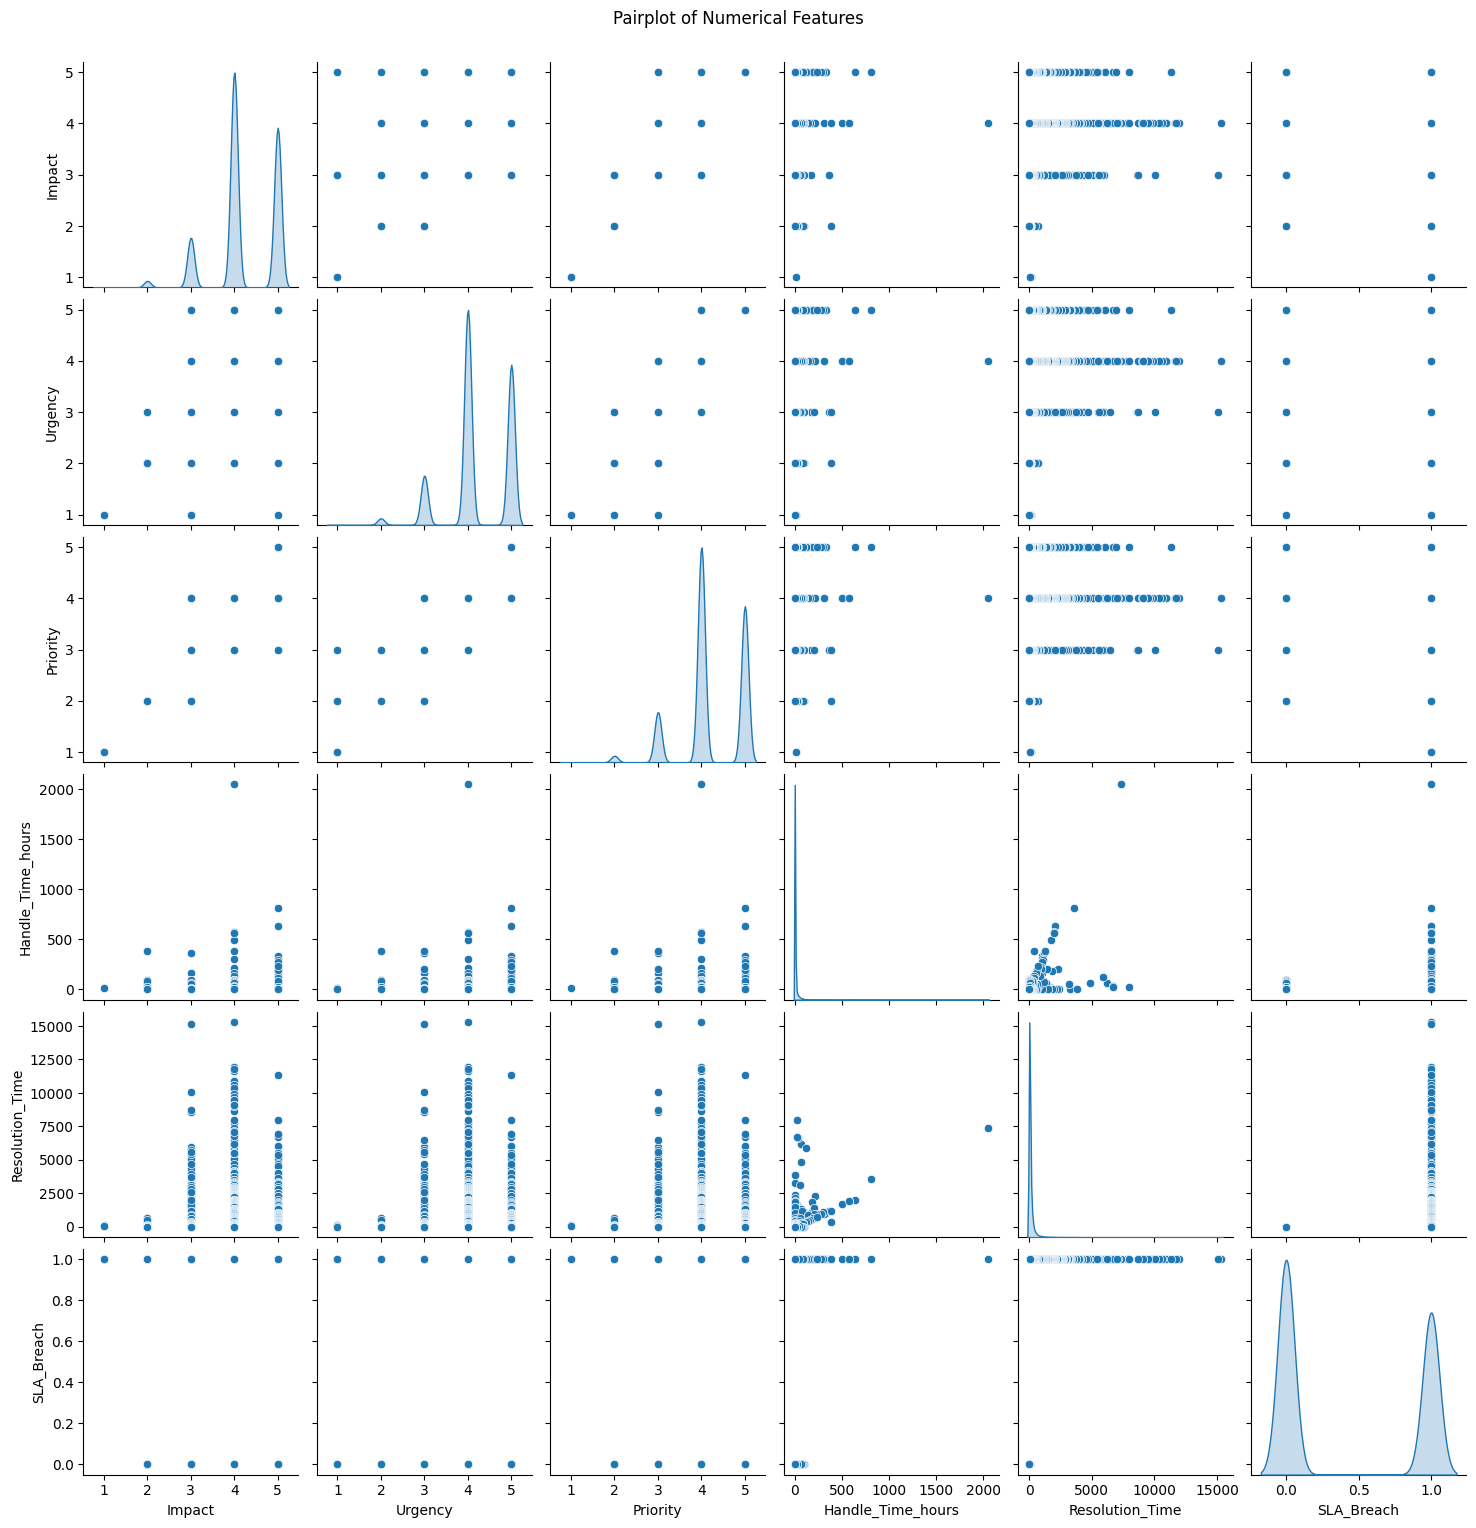

In [36]:
import os
os.makedirs("Images", exist_ok=True)

pair = sns.pairplot(
    df_model[numeric_cols],
    diag_kind="kde"
)

pair.fig.suptitle("Pairplot of Numerical Features", y=1.02)

pair.savefig("Images/pairplot.png")

plt.show()

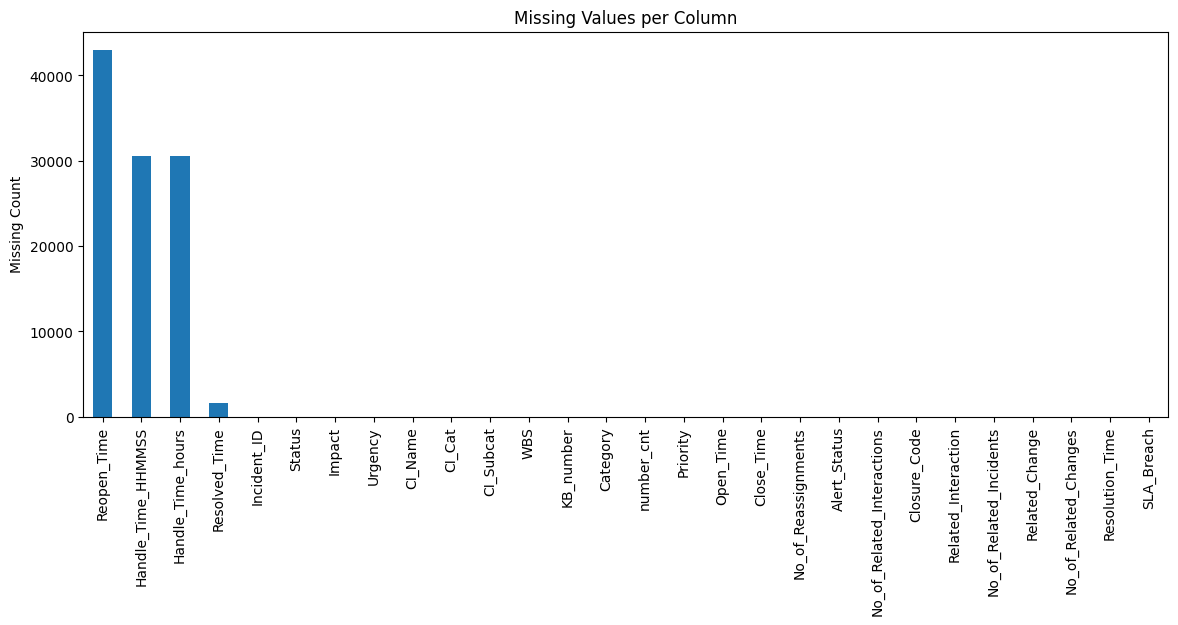

In [37]:
plt.figure(figsize=(14,5))
df_model.isna().sum().sort_values(ascending=False).plot(kind="bar")
plt.title("Missing Values per Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=90)

plt.savefig("Images/missing_values.png")
plt.show()

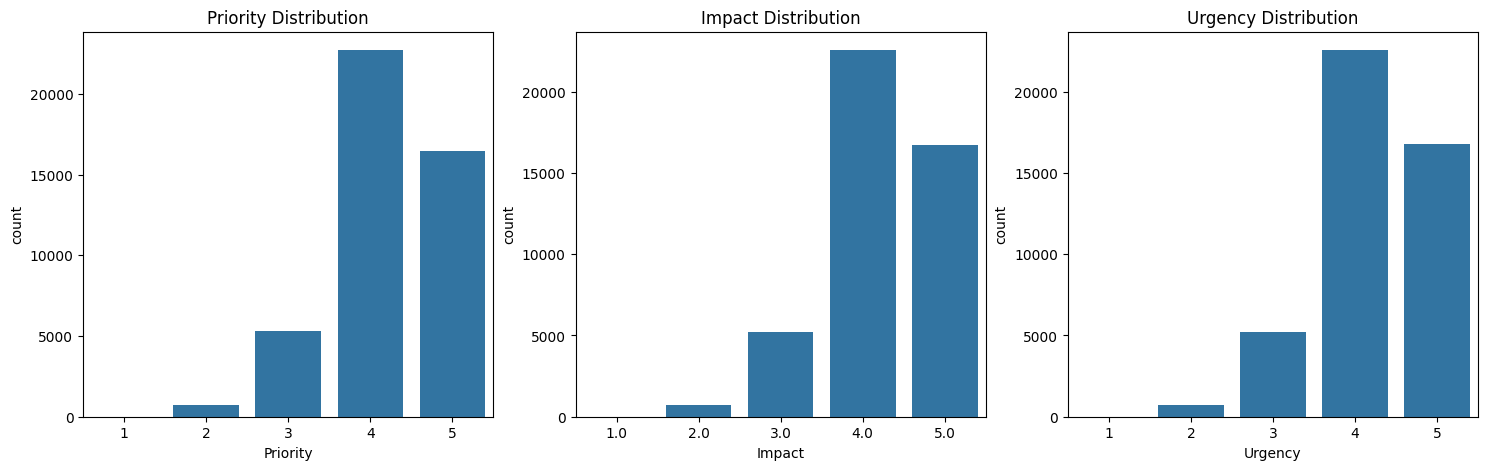

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x=df_model["Priority"], ax=ax[0])
ax[0].set_title("Priority Distribution")
plt.savefig("Images/Priority Distribution.png")

sns.countplot(x=df_model["Impact"], ax=ax[1])
ax[1].set_title("Impact Distribution")
plt.savefig("Images/Impact Distribution.png")

sns.countplot(x=df_model["Urgency"], ax=ax[2])
ax[2].set_title("Urgency Distribution")
plt.savefig("Images/Urgency Distribution.png")

plt.show()

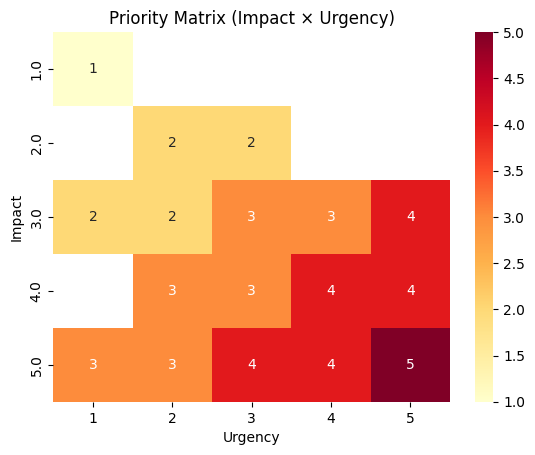

In [39]:
pivot = df_model.pivot_table(index="Impact", columns="Urgency", values="Priority", aggfunc="median")
sns.heatmap(pivot, annot=True, cmap="YlOrRd")
plt.title("Priority Matrix (Impact × Urgency)")

plt.savefig("Images/Priority Matrix (Impact × Urgency).png")
plt.show()

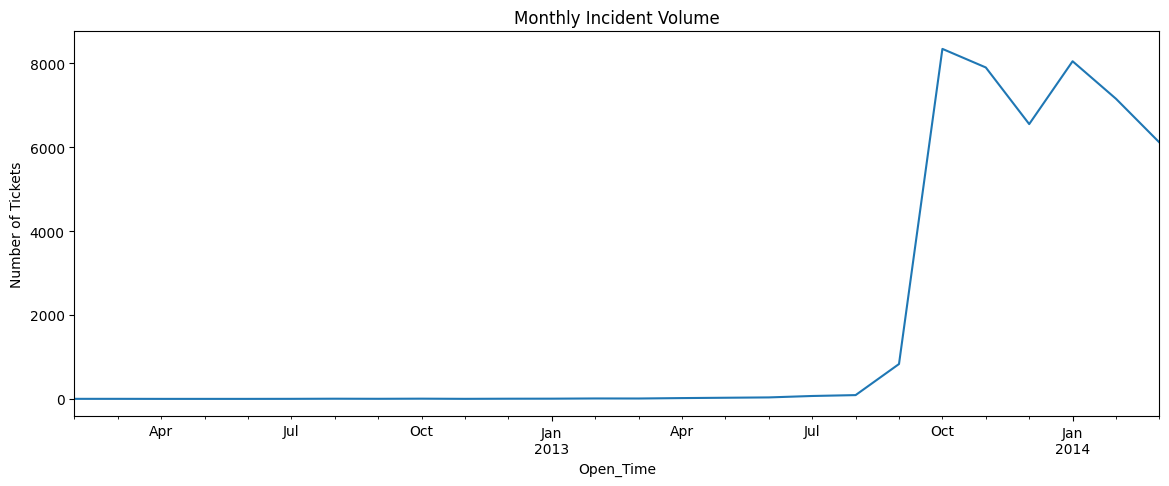

In [40]:
monthly = df_model.set_index("Open_Time").resample("M").size()

plt.figure(figsize=(14,5))
monthly.plot()
plt.title("Monthly Incident Volume")
plt.ylabel("Number of Tickets")

plt.savefig("Images/Monthly Incident Volume.png")
plt.show()

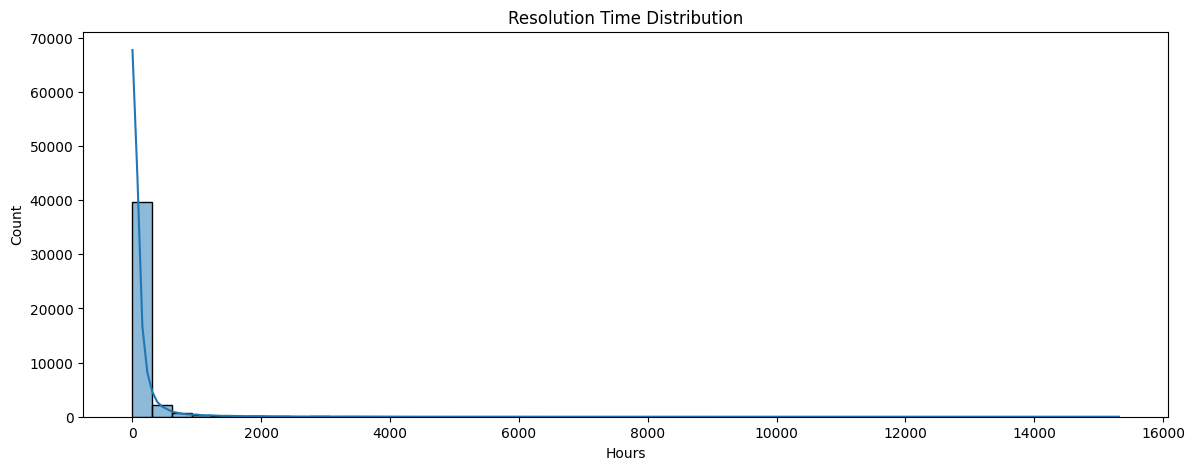

In [41]:
df_model["_resolve_time"] = (df_model["Resolved_Time"] - df_model["Open_Time"]).dt.total_seconds() / 3600

plt.figure(figsize=(14,5))
sns.histplot(df_model["_resolve_time"], kde=True, bins=50)
plt.title("Resolution Time Distribution")
plt.xlabel("Hours")

plt.savefig("Images/Resolution Time Distribution.png")
plt.show()

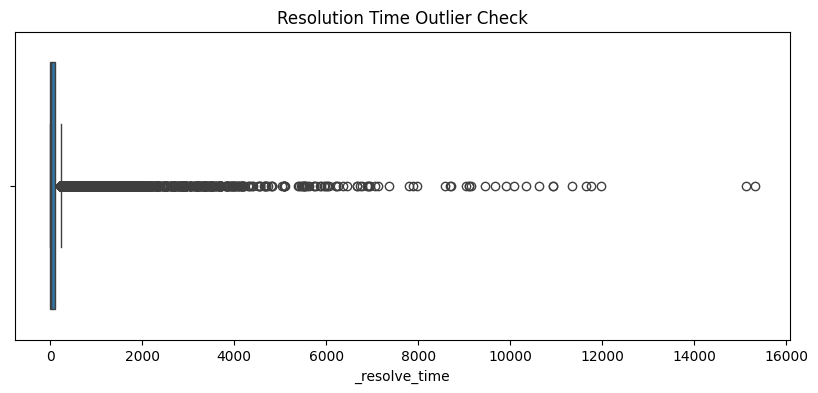

In [42]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_model["_resolve_time"])
plt.title("Resolution Time Outlier Check")

plt.savefig("Images/Resolution Time Outlier Check.png")
plt.show()


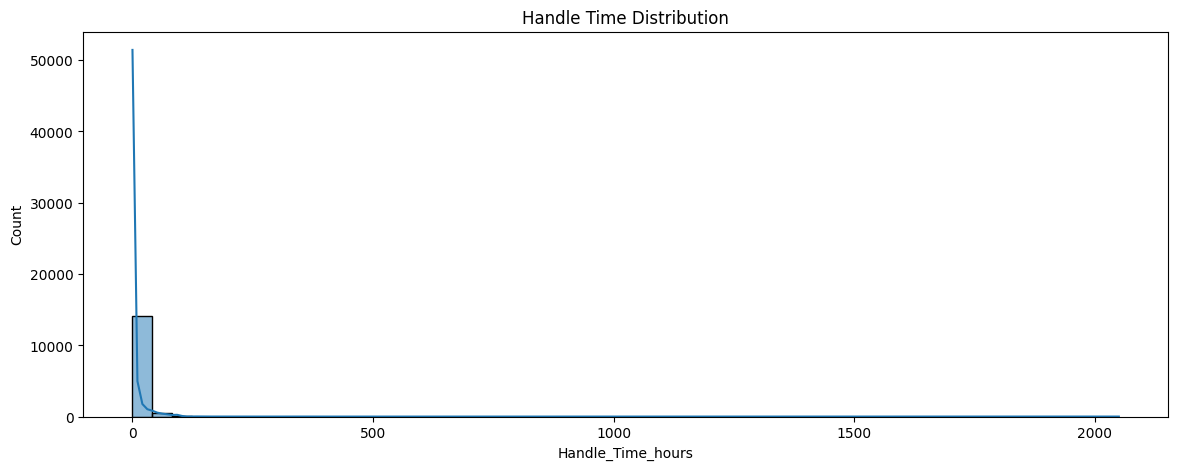

In [43]:
plt.figure(figsize=(14,5))
sns.histplot(df_model["Handle_Time_hours"], kde=True, bins=50)
plt.title("Handle Time Distribution")

plt.savefig("Images/Handle Time Distribution.png")
plt.show()

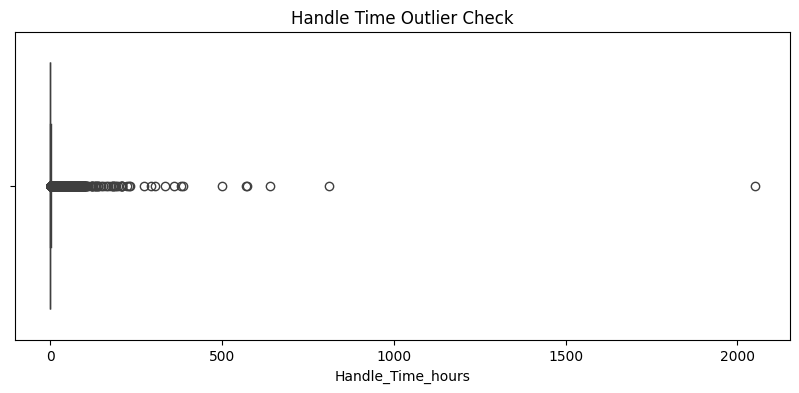

In [44]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_model["Handle_Time_hours"])
plt.title("Handle Time Outlier Check")

plt.savefig("Images/Handle Time Outlier Check.png")
plt.show()

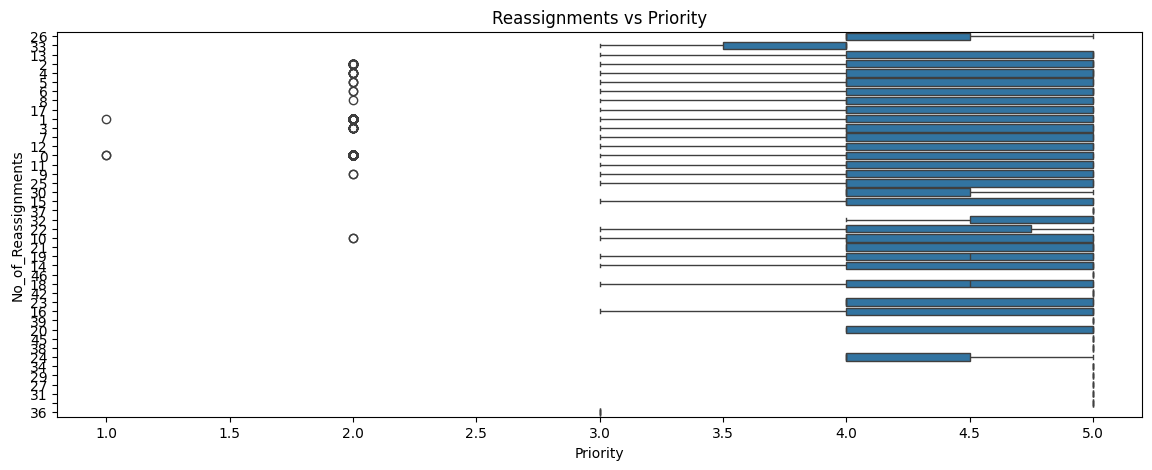

In [45]:
plt.figure(figsize=(14,5))
sns.boxplot(x=df_model["Priority"], y=df_model["No_of_Reassignments"])
plt.title("Reassignments vs Priority")

plt.savefig("Images/Reassignments vs Priority.png")
plt.show()

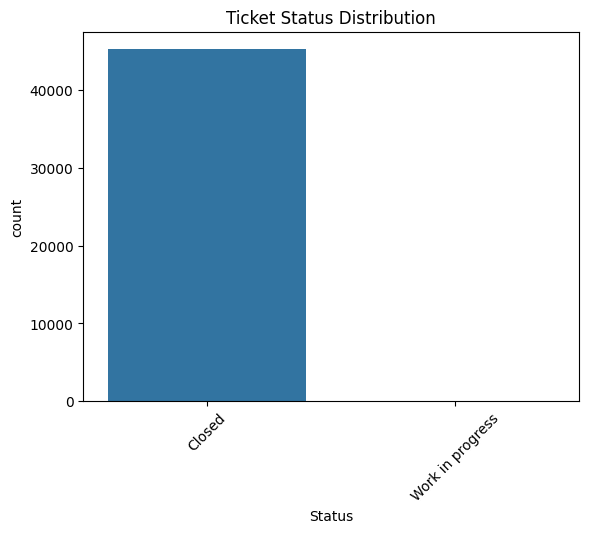

In [46]:
sns.countplot(x=df_model["Status"])
plt.title("Ticket Status Distribution")
plt.xticks(rotation=45)

plt.savefig("Images/Ticket Status Distribution.png")
plt.show()

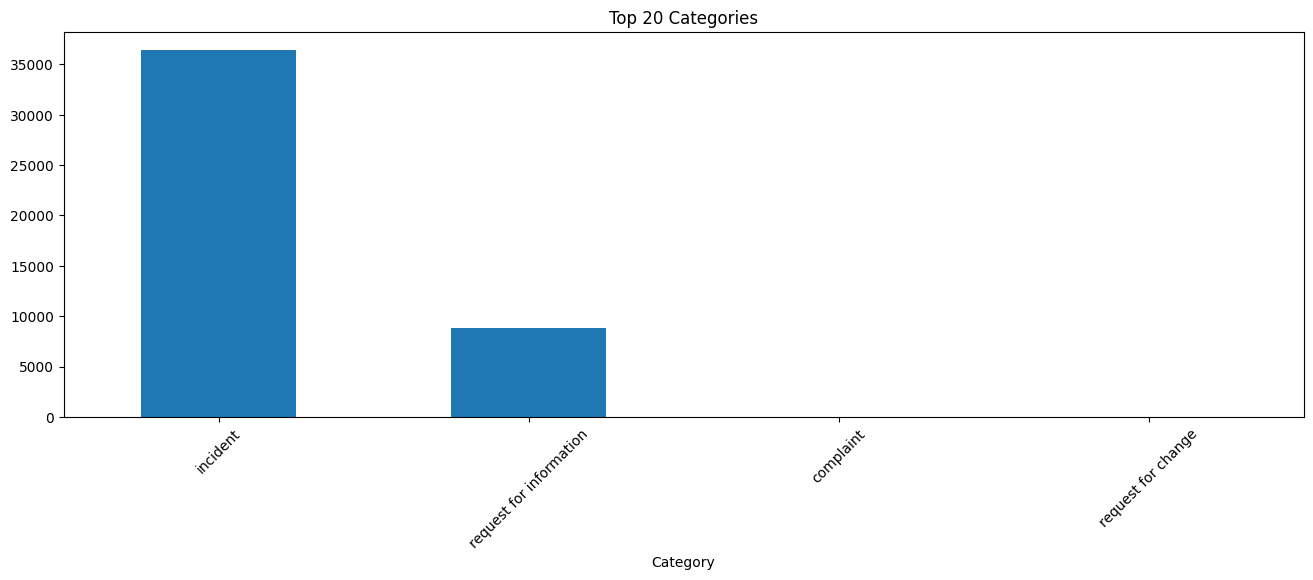

In [47]:
plt.figure(figsize=(16,5))
df_model["Category"].value_counts().head(20).plot(kind="bar")
plt.title("Top 20 Categories")
plt.xticks(rotation=45)

plt.savefig("Images/Top 20 Categories.png")
plt.show()

In [48]:
df_model[numeric_cols].corr()

,Impact,Urgency,Priority,Handle_Time_hours,Resolution_Time,SLA_Breach
Impact,1.000000,0.980101,0.991755,0.047286,0.039391,0.199710
Urgency,0.980101,1.000000,0.989828,0.044558,0.038040,0.196758
Priority,0.991755,0.989828,1.000000,0.045611,0.038447,0.197214
Handle_Time_hours,0.047286,0.044558,0.045611,1.000000,0.457088,0.235234
Resolution_Time,0.039391,0.038040,0.038447,0.457088,1.000000,0.305210
SLA_Breach,0.199710,0.196758,0.197214,0.235234,0.305210,1.000000


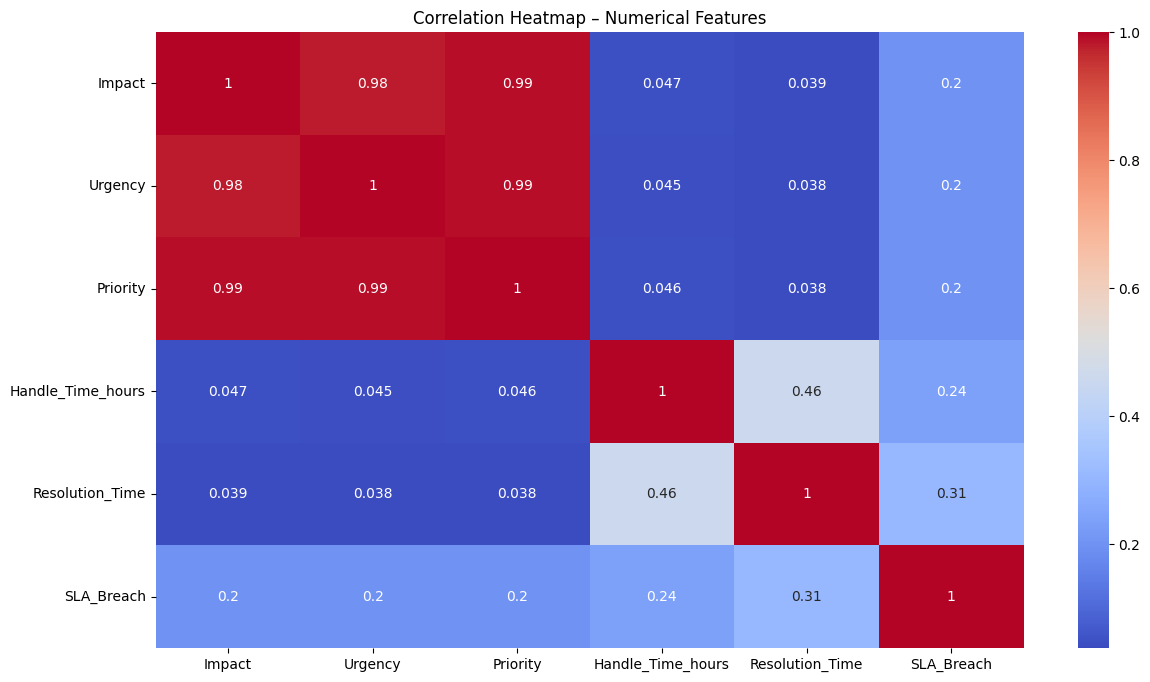

In [49]:
plt.figure(figsize=(14,8))
sns.heatmap(df_model[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap – Numerical Features")

plt.savefig("Images/Correlation Heatmap – Numerical Features.png")
plt.show()

In [50]:
df_model.isnull().sum()

CI_Name                           0
CI_Cat                            0
CI_Subcat                         0
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                          0
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               0
Open_Time                         0
Reopen_Time                   42987
Resolved_Time                  1644
Close_Time                        0
Closure_Code                      0
No_of_Related_Interactions        0
Related_Interaction               0
No_of_Related_Incidents           0
No_of_Related_Changes             0
Related_Change                    0
Handle_Time_hours             30564
Resolution_Time                   0
SLA_Breach                        0
Handle_Time_HHMMSS          

In [51]:
numeric_features = df_model.select_dtypes(include=['number']).columns
numeric_features

Index(['Impact', 'Urgency', 'Priority', 'Handle_Time_hours', 'Resolution_Time',
       'SLA_Breach', '_resolve_time'],
      dtype='object')

In [52]:
categorical_features = df_model.select_dtypes(include=['object']).columns
categorical_features

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'number_cnt', 'Category', 'KB_number', 'Alert_Status',
       'No_of_Reassignments', 'Closure_Code', 'No_of_Related_Interactions',
       'Related_Interaction', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'Related_Change', 'Handle_Time_HHMMSS'],
      dtype='object')

In [53]:
df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())

In [54]:
df_model[categorical_features] = df_model[categorical_features].fillna(df_model[categorical_features].mode().iloc[0])

In [55]:
df_model.isnull().sum()

CI_Name                           0
CI_Cat                            0
CI_Subcat                         0
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                          0
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               0
Open_Time                         0
Reopen_Time                   42987
Resolved_Time                  1644
Close_Time                        0
Closure_Code                      0
No_of_Related_Interactions        0
Related_Interaction               0
No_of_Related_Incidents           0
No_of_Related_Changes             0
Related_Change                    0
Handle_Time_hours                 0
Resolution_Time                   0
SLA_Breach                        0
Handle_Time_HHMMSS          

In [56]:
df_model.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change',
       'Handle_Time_hours', 'Resolution_Time', 'SLA_Breach',
       'Handle_Time_HHMMSS', '_resolve_time'],
      dtype='object')

In [57]:
numeric_features = df_model.select_dtypes(include=['number']).columns
numeric_features

Index(['Impact', 'Urgency', 'Priority', 'Handle_Time_hours', 'Resolution_Time',
       'SLA_Breach', '_resolve_time'],
      dtype='object')

In [58]:
categorical_features = df_model.select_dtypes(include=['object']).columns
categorical_features

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'number_cnt', 'Category', 'KB_number', 'Alert_Status',
       'No_of_Reassignments', 'Closure_Code', 'No_of_Related_Interactions',
       'Related_Interaction', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'Related_Change', 'Handle_Time_HHMMSS'],
      dtype='object')

In [59]:
df_t1 = df_model.copy()

In [60]:
df_t1.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change',
       'Handle_Time_hours', 'Resolution_Time', 'SLA_Breach',
       'Handle_Time_HHMMSS', '_resolve_time'],
      dtype='object')

In [61]:
df_t1["is_high_priority"] = (df_t1["Priority"].astype(int) <= 2).astype(int) 

In [62]:
df_t1["is_high_priority"].value_counts()

is_high_priority
0    44526
1      700
Name: count, dtype: int64

In [63]:
selected_cols = [
    # "Impact",
    # "Urgency",
    "Category",
    "CI_Cat",
    "CI_Subcat",
    "Status",
    "Alert_Status",
    "number_cnt",
    "No_of_Reassignments",
    "is_high_priority"
]

df_t1 = df_t1[selected_cols]

In [64]:
y = df_t1["is_high_priority"]
X = df_t1.drop(columns=["is_high_priority"])

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [66]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print('-'*60)

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print('-'*60)

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (36180, 7)
Test shape: (9046, 7)
------------------------------------------------------------
Train target distribution:
is_high_priority
0    0.984522
1    0.015478
Name: proportion, dtype: float64
------------------------------------------------------------
Test target distribution:
is_high_priority
0    0.984524
1    0.015476
Name: proportion, dtype: float64


In [67]:
categorical_t1 = ['Category', 'CI_Cat', 'CI_Subcat','Status', 'Alert_Status']
numeric_t1  = ['number_cnt', 'No_of_Reassignments'] 

In [68]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on TRAIN only
X_train_cat = encoder.fit_transform(X_train[categorical_t1])
encoded_cols = encoder.get_feature_names_out(categorical_t1)

X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)

# Transform TEST
X_test_cat = encoder.transform(X_test[categorical_t1])
X_test_cat = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

In [69]:
print(type(X_train))
print(type(X_test))
print(len(numeric_t1))
print(numeric_t1)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
2
['number_cnt', 'No_of_Reassignments']


In [70]:
import numpy as np

numeric_t1 = X_train.select_dtypes(include=np.number).columns
print(numeric_t1)

Index([], dtype='object')


In [71]:
print(numeric_t1)

Index([], dtype='object')


In [72]:
import numpy as np

numeric_t1 = X_train.select_dtypes(include=np.number).columns
print(numeric_t1)

Index([], dtype='object')


In [73]:
print(X_train.shape)
print(X_test.shape)

(36180, 7)
(9046, 7)


In [74]:
from sklearn.model_selection import train_test_split

X = df_model.drop("Priority", axis=1)
y = df_model["Priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
print(X_train[numeric_t1].dtypes)

Series([], dtype: object)


In [76]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# get numeric columns
numeric_t1 = X_train.select_dtypes(include=np.number).columns

scaler = StandardScaler()

# scale training data
X_train_num = scaler.fit_transform(X_train[numeric_t1])
X_train_num = pd.DataFrame(X_train_num, columns=numeric_t1, index=X_train.index)

# scale test data
X_test_num = scaler.transform(X_test[numeric_t1])
X_test_num = pd.DataFrame(X_test_num, columns=numeric_t1, index=X_test.index)

In [77]:
X_train_num.describe()

,Impact,Urgency,Handle_Time_hours,Resolution_Time,SLA_Breach,_resolve_time
count,3.618000e+04,3.618000e+04,3.618000e+04,3.618000e+04,36180.000000,3.618000e+04
mean,1.810725e-16,1.476861e-16,-8.641205e-18,1.963910e-17,0.000000,-6.677295e-18
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014,1.000014e+00
min,-4.563909e+00,-4.569354e+00,-1.319987e-01,-2.759080e-01,-0.867457,-2.755438e-01
25%,-3.149346e-01,-3.169517e-01,-1.036650e-01,-2.729841e-01,-0.867457,-2.722899e-01
50%,-3.149346e-01,-3.169517e-01,-1.036650e-01,-2.342327e-01,-0.867457,-2.321825e-01
75%,1.101390e+00,1.100516e+00,-1.036650e-01,-6.320091e-02,1.152794,-6.134795e-02
max,1.101390e+00,1.100516e+00,1.225307e+02,3.372833e+01,1.152794,3.448685e+01


In [78]:
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

In [79]:
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

print(X_train_final.shape)
print(X_test_final.shape)

(43464, 87)
(16330, 87)


In [80]:
X_train_final = X_train_final.fillna(0)
X_test_final = X_test_final.fillna(0)

In [81]:
print(X_train_final.shape)
print(X_test_final.shape)

(43464, 87)
(16330, 87)


In [82]:
print(X_train_final.shape)
print(y_train.shape)

(43464, 87)
(36180,)


In [83]:
X_train_final = X_train_final.loc[y_train.index]
X_test_final = X_test_final.loc[y_test.index]

In [84]:
print(X_train_final.shape)
print(y_train.shape)

(36180, 87)
(36180,)


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=500)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9998894539022772
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       132
           3       1.00      1.00      1.00      1067
           4       1.00      1.00      1.00      4515
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9046
   macro avg       1.00      1.00      1.00      9046
weighted avg       1.00      1.00      1.00      9046



In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=500)

log_model.fit(X_train_final, y_train)

y_pred_log = log_model.predict(X_test_final)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9998894539022772
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       132
           3       1.00      1.00      1.00      1067
           4       1.00      1.00      1.00      4515
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9046
   macro avg       1.00      1.00      1.00      9046
weighted avg       1.00      1.00      1.00      9046



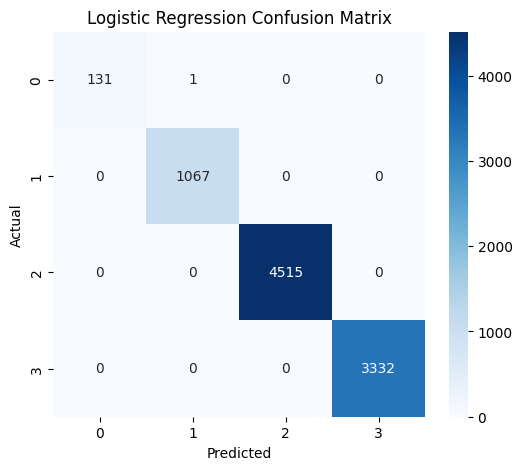

In [87]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=500)

log_model.fit(X_train_final, y_train)

y_pred_log = log_model.predict(X_test_final)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9998894539022772
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       132
           3       1.00      1.00      1.00      1067
           4       1.00      1.00      1.00      4515
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9046
   macro avg       1.00      1.00      1.00      9046
weighted avg       1.00      1.00      1.00      9046



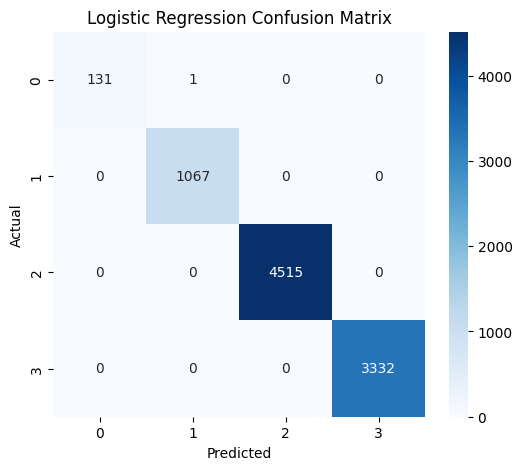

In [89]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_final, y_train)

y_pred_rf = rf_model.predict(X_test_final)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9996683617068317
              precision    recall  f1-score   support

           2       1.00      0.98      0.99       132
           3       1.00      1.00      1.00      1067
           4       1.00      1.00      1.00      4515
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9046
   macro avg       1.00      1.00      1.00      9046
weighted avg       1.00      1.00      1.00      9046



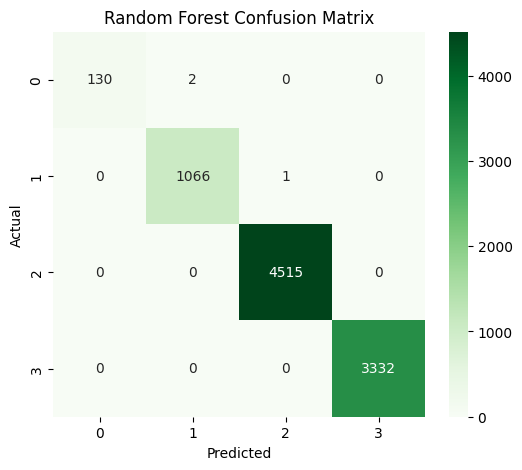

In [91]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

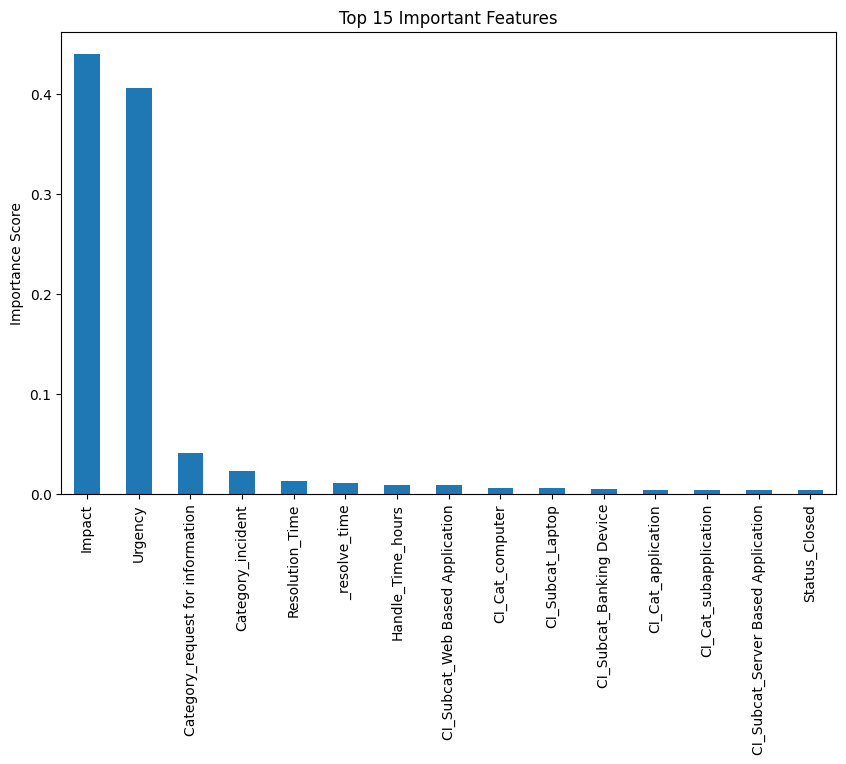

In [92]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X_train_final.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(15).plot(kind="bar")

plt.title("Top 15 Important Features")

plt.ylabel("Importance Score")

plt.show()

In [93]:
log_acc = accuracy_score(y_test, y_pred_log)

rf_acc = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.999889
1,Random Forest,0.999668


In [94]:
log_acc = accuracy_score(y_test, y_pred_log)

rf_acc = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.999889
1,Random Forest,0.999668


In [95]:
import joblib

joblib.dump(rf_model, "incident_priority_model.pkl")

['incident_priority_model.pkl']

In [96]:
model = joblib.load("incident_priority_model.pkl")

Key Insights

• Tickets with high urgency and impact are more likely to be high priority
• High number of reassignment increases resolution time
• Certain configuration items generate most incidents
• Random Forest performed better than Logistic Regression

Recommendations

• Use ML model to auto predict ticket priority
• Auto assign tickets to correct support group
• Monitor configuration items generating frequent incidents
• Use forecasting models to plan support resources

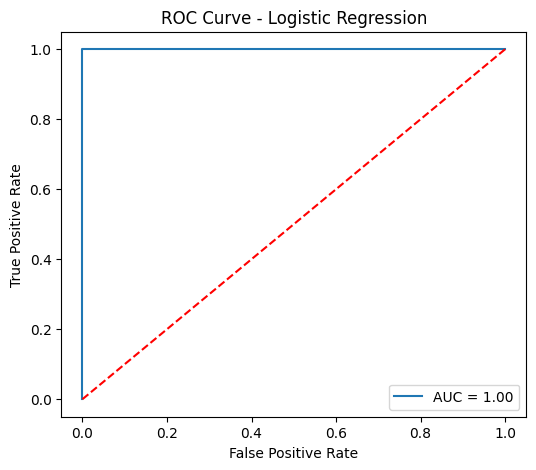

In [97]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert priority to binary (High priority vs others)
y_test_binary = (y_test <= 2).astype(int)

y_prob = log_model.predict_proba(X_test_final)[:,1]

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

ROC Curve evaluates the performance of the classification model.

The Area Under Curve (AUC) measures how well the model distinguishes between high priority and low priority incidents.

AUC close to 1 indicates a strong model.

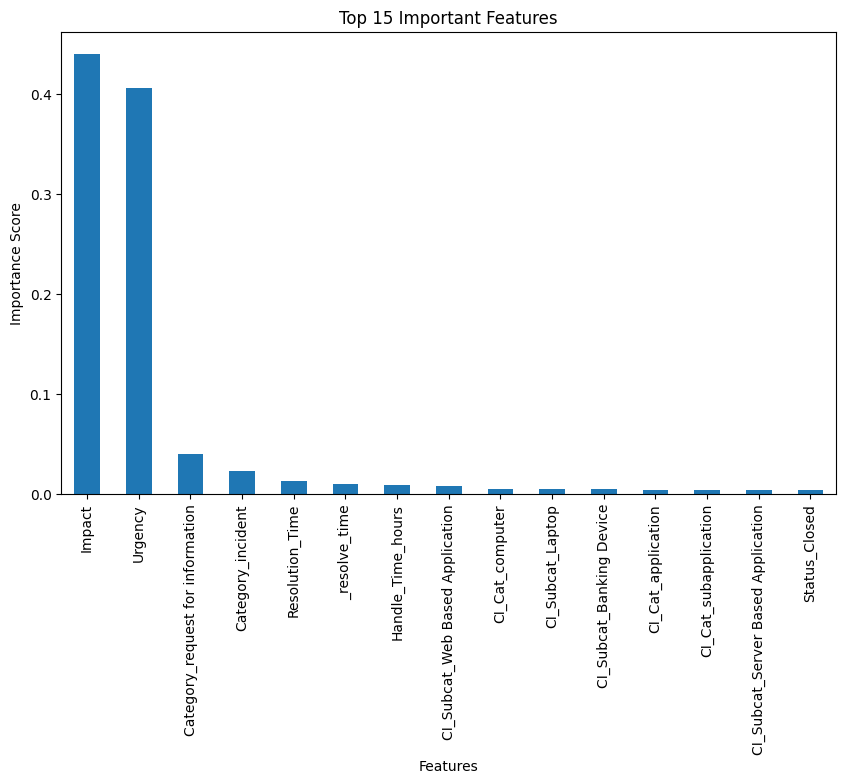

In [98]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X_train_final.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.head(15).plot(kind="bar")

plt.title("Top 15 Important Features")

plt.ylabel("Importance Score")

plt.xlabel("Features")

plt.show()

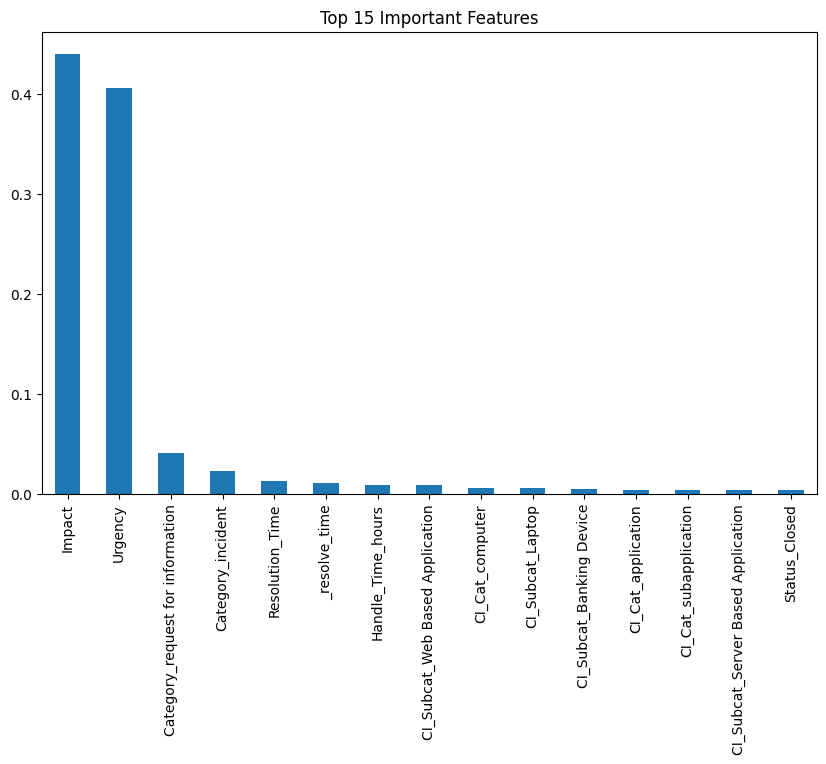

In [99]:
plt.figure(figsize=(10,6))

feature_importance.head(15).plot(kind="bar")

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png")

plt.show()

In [100]:
from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test, y_pred_log)

rf_acc = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.999889
1,Random Forest,0.999668


In [101]:
import joblib

joblib.dump(rf_model, "itsm_incident_priority_model.pkl")

['itsm_incident_priority_model.pkl']

In [102]:
model = joblib.load("itsm_incident_priority_model.pkl")

Key Insights

• High urgency and impact strongly influence ticket priority
• Tickets with high reassignment count often lead to longer resolution time
• Certain configuration items generate large number of incidents
• Random Forest model performed better than Logistic Regression

Recommendations

• Implement ML model to automatically predict ticket priority
• Reduce ticket reassignment using intelligent routing
• Monitor configuration items generating frequent incidents
• Use incident forecasting to improve resource planning